In [1]:
import vertexai 
import pandas as pd
from google import genai
import os 
import vertexai 
import pandas as pd
from google import genai
from ci_relevance_utils import relevance_prompt_v1, relevance_prompt_v2, get_secret, process_and_save_prompt_output, jsonl_to_df

In [2]:
PROJECT_ID = 'proj-sales-recommender-dev'
LOCATION = 'us-central1'
BUCKET = 'sales_recommender_dev_bucket'
DATASET_NAME = "data/cc_classification_sample_with_distances.csv"
SEARCHES_DATASET_NAME = "data/search_evaluation/searches.csv"
SECRET_NAME = "gemini_api_key"
MODEL_ID = "gemini-2.0-flash-001"

In [3]:
# Init vertex 
vertexai.init(project=PROJECT_ID, location=LOCATION)

# Create client using secret manager
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "key.json"
os.environ["GEMINI_API_KEY"] = get_secret(PROJECT_ID, SECRET_NAME)
gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [4]:
# Read dataset
df = pd.read_csv(f"gs://{BUCKET}/{DATASET_NAME}")

In [5]:
def remap_search(search): 
    keywords = ["Drywall", "Ceiling", "Insulation", "EIFS", "Core", "Cultured Stone", "FRP", "Fry Reglet", "Steel", "Door"]
    for word in keywords: 
        if word in search: 
            if word == 'Ceiling': 
                return 'Ceilings'
            return word
    return search

In [6]:
# Rename search terms
df['Search'] = df['Search'].apply(remap_search)
searches_df = pd.read_csv("searches.csv")
search_map={}

# Fetch queries based on search names
for idx, row in searches_df.iterrows(): 
    search = row['SEARCH']
    filter = row['NEW_FILTER']
    search_map[search] = filter

# Apply new queries from the search evaluation
df['Query_new'] = df['Search'].apply(lambda x: search_map[x] if x in search_map else x)
df.drop(columns=['Query'], inplace=True)

In [7]:
# Fetch rows which were not labeled correctly originally (correct used for few-shot)
test_df = df[df['True Relevance'] != df['Relevance']]
test_df.drop(columns=['Relevance'], inplace=True)

/var/folders/t9/ynlywvys31d_71jprr25h4c00000gn/T/ipykernel_42473/1831570390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop(columns=['Relevance'], inplace=True)


In [8]:
# Make directory for predictions
os.makedirs("predictions/relevance/ci_interval", exist_ok=True)

In [9]:
# Make predictions using standard examples
process_and_save_prompt_output(gemini_client=gemini_client,
                                model_id=MODEL_ID,
                                prompt_function=relevance_prompt_v1,
                                df=test_df,
                                search_col='Search', 
                                query_col='Query_new',
                                relevance_col='True Relevance', 
                                reasoning_col='Reasoning',
                                output_filename='predictions/relevance/ci_interval/no_intervals.jsonl', 
)

 68%|██████▊   | 42/62 [00:46<00:21,  1.09s/it]

No examples found for search: FRP


 85%|████████▌ | 53/62 [00:56<00:08,  1.03it/s]

No examples found for search: FRP


100%|██████████| 62/62 [01:07<00:00,  1.09s/it]


In [10]:
# Make predictions using new prompts with intervals
process_and_save_prompt_output(gemini_client=gemini_client,
                                model_id=MODEL_ID,
                                prompt_function=relevance_prompt_v2,
                                df=test_df,
                                search_col='Search', 
                                query_col='Query_new',
                                relevance_col='True Relevance', 
                                reasoning_col='Reasoning',
                                output_filename='predictions/relevance/ci_interval/use_intervals.jsonl', 
)

 68%|██████▊   | 42/62 [00:51<00:22,  1.11s/it]

No examples found for search: FRP


 85%|████████▌ | 53/62 [01:03<00:10,  1.15s/it]

No examples found for search: FRP


100%|██████████| 62/62 [01:13<00:00,  1.19s/it]


In [11]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
mapping = {'very high': 'high', 'high': 'high', 'moderate': 'moderate', 'low': 'low', 'very low': 'low', 'not relevant': 'low'}
labels = ['low', 'moderate', 'high']
encoder = LabelEncoder()
encoder.fit(labels)

# Map labels and encode relevance columns
def map_and_encode_relevance(df, encoder, mapping): 
    return_df = df.copy()
    for col in ['True Relevance', 'Relevance']: 
        return_df.loc[:, col] = return_df[col].str.lower()
        return_df.loc[:, col] = return_df[col].replace(mapping)
        return_df.loc[:, f"{col}_label"] = encoder.transform(return_df[col])
    return return_df

### Process results with no confidence intervals

In [12]:
responses_df = test_df.copy() 

no_intervals_preds = jsonl_to_df("predictions/relevance/ci_interval/no_intervals.jsonl")
no_intervals_preds = pd.merge(responses_df, no_intervals_preds, how='left', on = 'ProjectID')

In [13]:
# Drop rows with "not relevant" label
no_intervals_preds = no_intervals_preds[(no_intervals_preds['Relevance'].str.lower() != 'not relevant') &  
                                        (no_intervals_preds['True Relevance'].str.lower() != 'not relevant')]

no_intervals_preds = map_and_encode_relevance(no_intervals_preds, encoder, mapping)
print(f"Number of relevant predictions: {len(no_intervals_preds)}")

Number of relevant predictions: 50


### Process results with confidence intervals

In [14]:
intervals_preds = jsonl_to_df("predictions/relevance/ci_interval/use_intervals.jsonl")
intervals_preds = pd.merge(responses_df, intervals_preds, how='left', on = 'ProjectID')

In [15]:
# Filter df by confidence interval and encode relevance columns
def drop_low_confidence_and_encode(df, threshold): 

    df = df.copy()

    # Drop rows with confidence below threshold
    low_confidence_mask = df['Confidence'] < threshold
    df.loc[low_confidence_mask, 'Relevance'] = 'low confidence'

    # Drop rows with "not relevant" or "low confidence" label
    df = df[(df['Relevance'] != 'low confidence') & 
            (df['Relevance'].str.lower() != 'not relevant') &
            (df['True Relevance'].str.lower() != 'not relevant')]
    
    df = map_and_encode_relevance(df, encoder, mapping)
    print(f"Number of relevant predictions after dropping confidence below {threshold}: {len(df)}")

    return df

In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score
from tabulate import tabulate
import numpy as np

headers = ["Version", "F1", "Precision"]
metrics_data = []

# Calculate metrics
for item in [(no_intervals_preds, "No Interval"), (intervals_preds, "Interval")]:

    df, label = item

    if label == "Interval": 

        # Calculate metrics for different thresholds
        for threshold in [1.0, 0.9, 0.8, 0.7]:

            # Drop rows with low confidence and encode relevance columns
            dropped_df = drop_low_confidence_and_encode(df, threshold)
            
            f1 = f1_score(dropped_df['True Relevance_label'], dropped_df['Relevance_label'], average='weighted')
            recall = recall_score(dropped_df['True Relevance_label'], dropped_df['Relevance_label'], average='weighted')
            precision = precision_score(dropped_df['True Relevance_label'], dropped_df[f"Relevance_label"], average='weighted', zero_division=np.nan)
            metrics_data.append([f"{label} Threshold: {str(threshold)}", f1, precision])

    else: 
        
        f1 = f1_score(df['True Relevance_label'], df['Relevance_label'], average='weighted')
        recall = recall_score(df['True Relevance_label'], df['Relevance_label'], average='weighted')
        precision = precision_score(df['True Relevance_label'], df[f"Relevance_label"], average='weighted', zero_division=np.nan)
        metrics_data.append([label, f1, precision])

table = tabulate(metrics_data, headers = headers, tablefmt="grid")

# Display metrics
print(table)

Number of relevant predictions after dropping confidence below 1.0: 29
Number of relevant predictions after dropping confidence below 0.9: 34
Number of relevant predictions after dropping confidence below 0.8: 42
Number of relevant predictions after dropping confidence below 0.7: 45
+-------------------------+----------+-------------+
| Version                 |       F1 |   Precision |
+=========================+==========+=============+
| No Interval             | 0.610136 |    0.827267 |
+-------------------------+----------+-------------+
| Interval Threshold: 1.0 | 0.789116 |    0.797241 |
+-------------------------+----------+-------------+
| Interval Threshold: 0.9 | 0.819874 |    0.826471 |
+-------------------------+----------+-------------+
| Interval Threshold: 0.8 | 0.78767  |    0.833643 |
+-------------------------+----------+-------------+
| Interval Threshold: 0.7 | 0.777251 |    0.846689 |
+-------------------------+----------+-------------+


/var/folders/t9/ynlywvys31d_71jprr25h4c00000gn/T/ipykernel_42473/1684202464.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Relevance', bbox_to_anchor=(1.05, 1), loc='upper left')


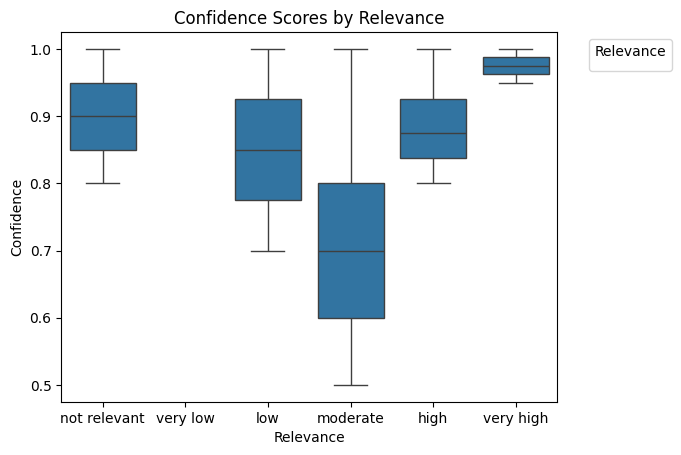

In [35]:
# Scatter plot for Confidence scores
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Relevance and Confidence to count occurrences
grouped_data = intervals_preds.groupby(['Relevance', 'Confidence']).size().reset_index(name='Count')
relevance_order = ['not relevant', 'very low', 'low', 'moderate', 'high', 'very high']

sns.boxplot(data=grouped_data, x='Relevance', y='Confidence',
                order = relevance_order)

plt.title('Confidence Scores by Relevance')
# plt.xticks(ticks=range(len(relevance_order)), labels=relevance_order, rotation=45)
plt.xlabel('Relevance')
plt.ylabel('Confidence')

# Move the legend outside the graph
plt.legend(title='Relevance', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()